In [4]:
import numpy as np
import math
import matplotlib.pyplot as plt
from typing import Callable, List, Tuple

In [2]:
data = [
    [
        [0.28, 1.31, -6.2],
        [0.07, 0.58, -0.78],
        [1.54, 2.01, -1.63],
        [-0.44, 1.18, -4.32],
        [-0.81, 0.21, 5.73],
        [1.52, 3.16, 2.77],
        [2.20, 2.42, -0.19],
        [0.91, 1.94, 6.21],
        [0.65, 1.93, 4.38],
        [-0.26, 0.82, -0.96],
    ],
    [
        [0.011, 1.03, -0.21],
        [1.27, 1.28, 0.08],
        [0.13, 3.12, 0.16],
        [-0.21, 1.23, -0.11],
        [-2.18, 1.39, -0.19],
        [0.34, 1.96, -0.16],
        [-1.38, 0.94, 0.45],
        [-0.12, 0.82, 0.17],
        [-1.44, 2.31, 0.14],
        [0.26, 1.94, 0.08],
    ],
    [
        [1.36, 2.17, 0.14],
        [1.41, 1.45, -0.38],
        [1.22, 0.99, 0.69],
        [2.46, 2.19, 1.31],
        [0.68, 0.79, 0.87],
        [2.51, 3.22, 1.35],
        [2.60, 2.44, 0.92],
        [0.64, 0.13, 0.97],
        [0.85, 0.58, 0.99],
        [0.66, 0.51, 0.88],
    ],
]

In [40]:
def gaussian_phi(x: Tuple[float, float, float]) -> float:
    x2 = sum([i * i for i in x])
    return math.e ** (-x2 / 2)


def parzen_estimate(
    data: List[Tuple[float, float, float]],
    x: Tuple[float, float, float],
    h: float = 1,
    phi: Callable[[float, float, float, float], float] = None,
) -> float:
    if phi is None:
        phi = gaussian_phi
    n = len(data)
    d = len(data[0])
    ans = 0
    for datum in data:
        shifted_data = ((x[i] - datum[i]) / h for i in range(d))
        ans += (1 / h**d) * phi(shifted_data)
    return ans / n


def classify(x: Tuple[float, float, float], h: float):
    ind = 0
    score = 0
    for i in range(3):
        new_score = parzen_estimate(
            data=data[i],
            x=x,
            h=h,
        )
        print(new_score)
        if new_score > score:
            ind = i
            score = new_score
    return ind


points = [
    (0.5, 1, 0),
    (0.31, 1.51, -0.5),
    (-0.3, 0.44, -0.1),
]

In [41]:
for p in points:
    print(p, classify(p, 1))

0.1259189799723306
0.47107849938547625
0.3774655703506812
(0.5, 1, 0) 1
0.15343855472566376
0.48279632750342605
0.2050403178919641
(0.31, 1.51, -0.5) 1
0.1399081189497749
0.37825432795011144
0.1770663572472812
(-0.3, 0.44, -0.1) 1


In [42]:
for p in points:
    print(p, classify(p, 0.1))

8.774695306732919e-20
6.769019526350558e-05
8.000188850603643e-17
(0.5, 1, 0) 1
2.8711163529583633e-20
1.2001838219399246e-05
2.1593289688030186e-25
(0.31, 1.51, -0.5) 1
3.6371227610424425e-12
0.00037830940387857903
1.0640260760706417e-39
(-0.3, 0.44, -0.1) 1


/var/folders/0m/wjwgxmxs2xl1pdp5hqg8qgr00000gn/T/ipykernel_95208/2032724060.py:15: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(x, y, z,  cmap='viridis', alpha=0.7, s=50, label=i)
/var/folders/0m/wjwgxmxs2xl1pdp5hqg8qgr00000gn/T/ipykernel_95208/2032724060.py:20: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(x, y, z,  cmap='viridis', alpha=0.7, s=50, label="points")


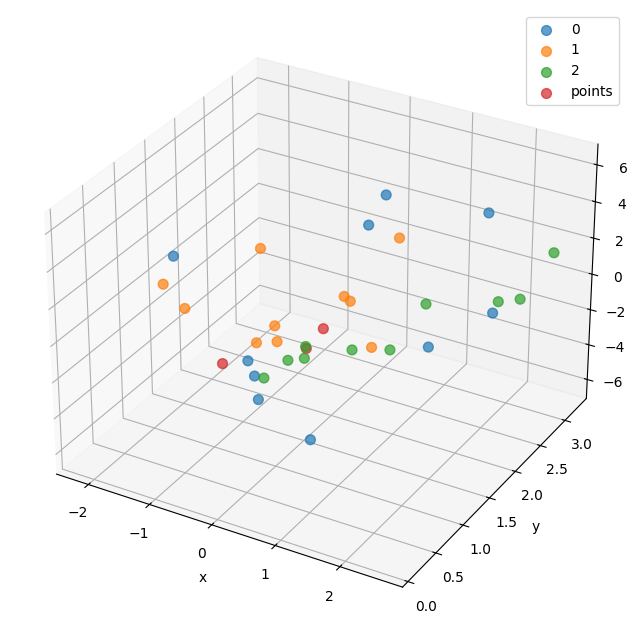

In [43]:
# Create some sample data
np.random.seed(42)
n_points = 100
x = np.random.randn(n_points)
y = np.random.randn(n_points)
z = np.random.randn(n_points)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

for i in range(3):
    x = [p[0] for p in data[i]]
    y = [p[1] for p in data[i]]
    z = [p[2] for p in data[i]]
    scatter = ax.scatter(x, y, z, cmap="viridis", alpha=0.7, s=50, label=i)

x = [p[0] for p in points]
y = [p[1] for p in points]
z = [p[2] for p in points]
scatter = ax.scatter(x, y, z, cmap="viridis", alpha=0.7, s=50, label="points")
ax.set_zlabel("z")
ax.set_ylabel("y")
ax.set_xlabel("x")
plt.legend()